  🖼️  Image     : /content/drive/MyDrive/Test_CV/Test_image19.png
  ✅ Prédiction : Canker
  🎯 Confiance  : 88.16%

📊 Probabilités par classe :
  Anthracnose          2.29%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Ash weevil           2.00%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Canker               88.16%  ██████████████████████████░░░░  ✅
  Greening             2.12%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Healthy              2.45%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Leaf miner           2.98%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


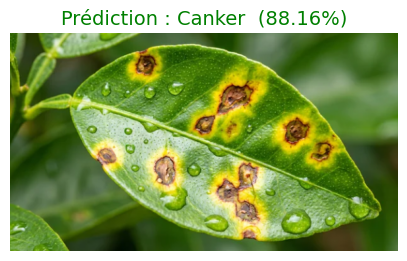

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────────────
IMAGE_PATH = '/content/drive/MyDrive/Test_CV/Test_image19.png'   # 👈 ton image
MODEL_PATH = '/content/drive/MyDrive/best_model_finetuned.pth' # Fixed: Updated model path

# 👇 Mets exactement les mêmes classes que ton entraînement (ordre alphabétique)
class_names = ['Anthracnose', 'Ash weevil', 'Canker', 'Greening', 'Healthy', 'Leaf miner']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── CHARGEMENT MODÈLE ──────────────────────────────────────────────────────────
num_classes = len(class_names)
model = models.mobilenet_v3_large(weights=None)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# ── PRÉTRAITEMENT IMAGE ────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image = Image.open(IMAGE_PATH).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)  # ajoute batch dimension

# ── INFÉRENCE ──────────────────────────────────────────────────────────────────
with torch.no_grad():
    outputs = model(input_tensor)
    probs   = torch.softmax(outputs, dim=1)[0]
    pred_idx = probs.argmax().item()

# ── RÉSULTATS ──────────────────────────────────────────────────────────────────
print('=' * 40)
print(f'  🖼️  Image     : {IMAGE_PATH}')
print(f'  ✅ Prédiction : {class_names[pred_idx]}')
print(f'  🎯 Confiance  : {probs[pred_idx]:.2%}')
print('=' * 40)
print('\n📊 Probabilités par classe :')
for i, (cls, prob) in enumerate(zip(class_names, probs)):
    bar    = '█' * int(prob * 30) + '░' * (30 - int(prob * 30))
    marker = '  ✅' if i == pred_idx else ''
    print(f'  {cls:<20} {prob:.2%}  {bar}{marker}')

# ── AFFICHAGE IMAGE ────────────────────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f'Prédiction : {class_names[pred_idx]}  ({probs[pred_idx]:.2%})',
          fontsize=14, color='green')
plt.axis('off')
plt.show()